The overall goal of this project is to find the set of controls (accelerator position, brake pressed, steering) for an optimised speed input (speed, position).
- Steering data is unavailable, so is currently out of scope.
- FSGP data from 2024 July, potentially over like 2-3 days (16-18 July)

current ideas for a workflow:

- using a RNN for a state to control model.
- we are mapping state inputs (velocity, position) to control (accel, brake pressed, steering)
- a question is - position as a dependent of speed, but i feel like it makes sense to use it anyways because otherwise the model wouldn't be able to pinpoint that particular part of the track with corresponding cornering/acceleration changes.


other references:
https://docs.google.com/spreadsheets/d/1yjyuKODt6wtIB31OLfhpwe0kKQ4CeoXJ/edit?gid=159364596#gid=159364596
- this document has lap timings
- i also used Miguel's monday updates to find which laps were ignored/had issues
- for now the RNN does not need to distinguish between laps, but  i wonder if that could be a possible input

In [289]:
#other references :


In [1]:
# query data from influx. looking at timestamps of 2024 FSGP: 14 - 18 overall, but for smaller data response lets try 14 -16

from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os
import pytz
from datetime import datetime, time, date

#each 5 seconds
utc_offset_h = 7
start_utc = time(0+utc_offset_h, 00, 00)  #querying i svancouver time, influxdb gives utc
stop_utc = time(16+utc_offset_h, 45, 00)
date_start = date(2024, 7, 16)
date_stop = date(2024, 7, 18)

vancouver = pytz.timezone("America/Vancouver")

start_local = vancouver.localize(datetime.combine(date_start, start_utc))
stop_local = vancouver.localize(datetime.combine(date_stop, stop_utc))

start_time = start_local.astimezone(pytz.utc)
stop_time = stop_local.astimezone(pytz.utc)

client = query.DBClient()
mech_brake_pressed: TimeSeries = client.query_time_series(start_time, stop_time, field="MechBrakePressed")
accel_position: TimeSeries =   client.query_time_series(start_time, stop_time, field="AcceleratorPosition")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "VehicleVelocity")



In [2]:
# speed is most likely in m/s

In [3]:
#necessary imports
import sklearn as sk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DataPreprocessing import make_sequence_datasets

In [4]:

# save collected data

out_dir = os.path.join("data", "control_state_fsgp_2024")
os.makedirs(out_dir, exist_ok=True)

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]
datasets = [mech_brake_pressed, accel_position, speed_kph]

for filepath, data in zip(filepaths, datasets):
    with open(filepath, "wb") as f:
        dill.dump(data, f)


In [5]:
import os
import dill

# same directory you used for saving
out_dir = os.path.join("data", "control_state_fsgp_2024")

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]

loaded_datasets = []

for filepath in filepaths:
    with open(filepath, "rb") as f:
        data = dill.load(f)
        loaded_datasets.append(data)

# unpack them
mech_brake_pressed, accel_position, speed_kph = loaded_datasets

In [6]:
mech_brake_pressed.granularity
#granularity is at 0.1 seconds

/var/folders/33/nmg1klvd6_d6wfzct17kl9rw0000gn/T/ipykernel_11022/3191881882.py:1: DeprecationWarning: Please use TimeSeries.period instead of TimeSeries.granularity
  mech_brake_pressed.granularity


np.float64(0.10000002186928031)

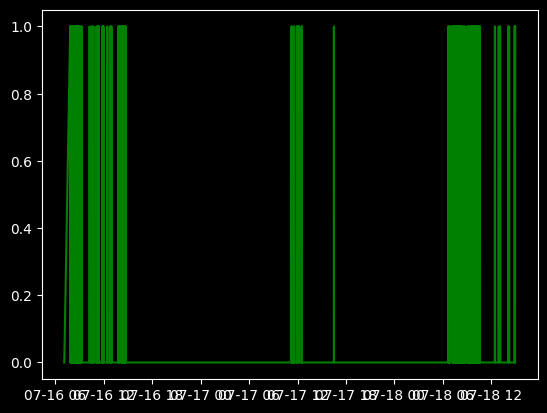

In [7]:
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")

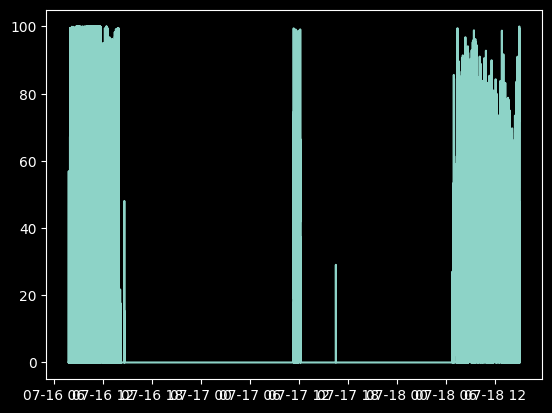

In [8]:

plt.plot(accel_position.datetime_x_axis, accel_position, label = "Accelerator Position")


In [9]:
# accel position and brake pressed are in inconsistent units, so i'll probbaly change them to a 0-1 range.

#using min, max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_accel_position = scaler.fit_transform(accel_position.reshape(-1, 1))




Text(0.5, 1.0, 'speed kph')

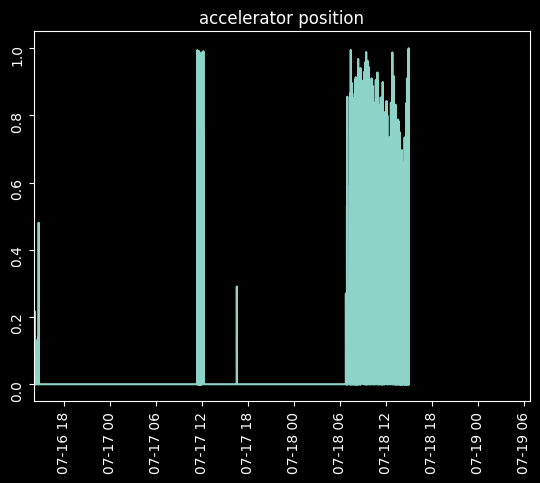

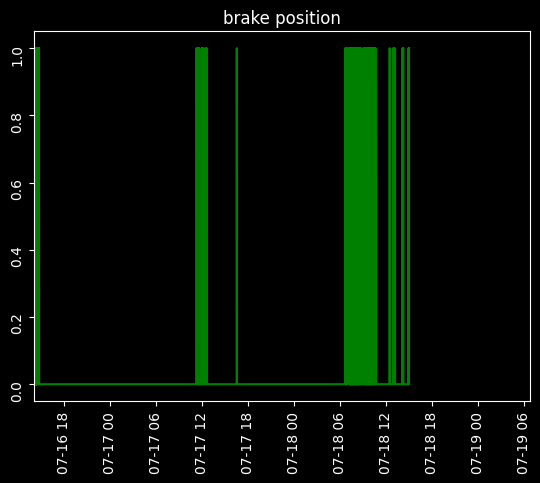

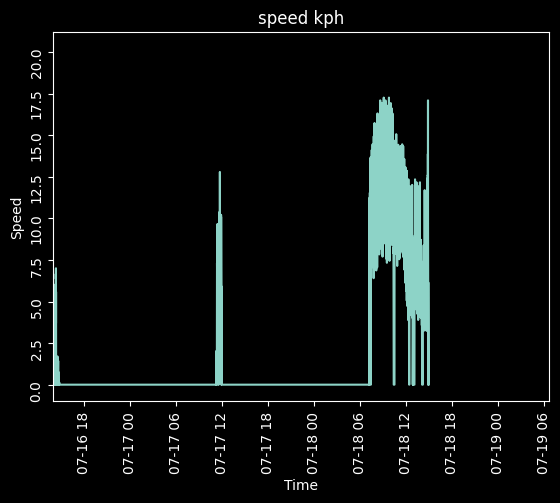

In [10]:
plt.figure(1)
plt.plot(accel_position.datetime_x_axis, scaled_accel_position, label = "Accelerator Position")
plt.xlim(start_time, stop_time)
plt.title("accelerator position")
plt.tick_params(rotation = 90)

plt.figure(2)
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")
plt.title("brake position")
plt.tick_params(rotation = 90)
plt.xlim(start_time, stop_time)
plt.figure(3)
# position is defined as a percentage

plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)
plt.xlim(start_time, stop_time)
plt.title("speed kph")


In [11]:
# why does brake pressed look more continous then acceleartor - accelerator seems like it is either 100% or none
# a good place where this lines up is

Text(0.5, 1.0, 'speed kph')

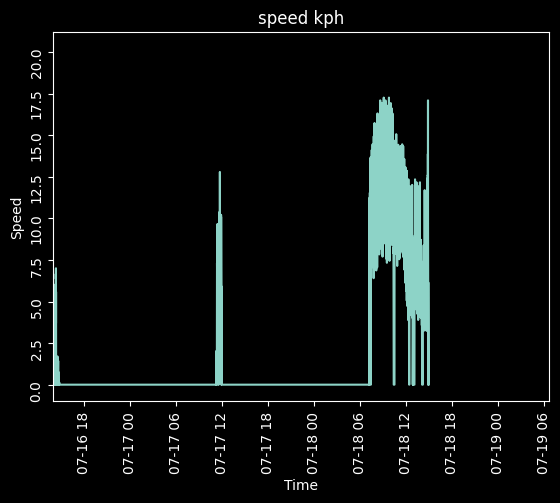

In [12]:
plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)
plt.xlim(start_time, stop_time)
plt.title("speed kph")

# what is up with the whack units



In [13]:
#clearly speed units are whack. from looking at lap data, i see that out average speed was around 16 miles per hour. so i think due to hwo influx registers small numbers in different units

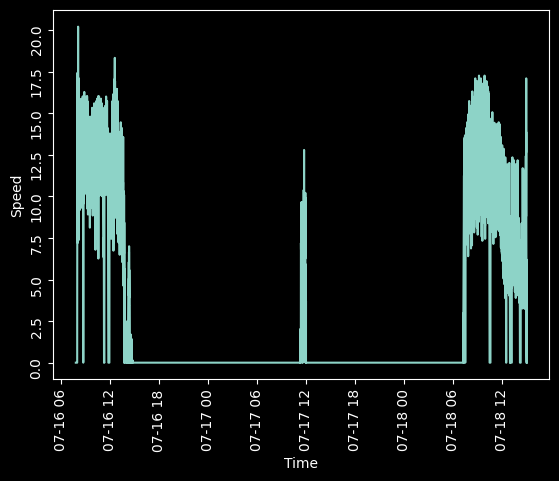

In [14]:
# position is defined as a percentage

plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)

/var/folders/33/nmg1klvd6_d6wfzct17kl9rw0000gn/T/ipykernel_11022/3599632894.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc = "upper left")


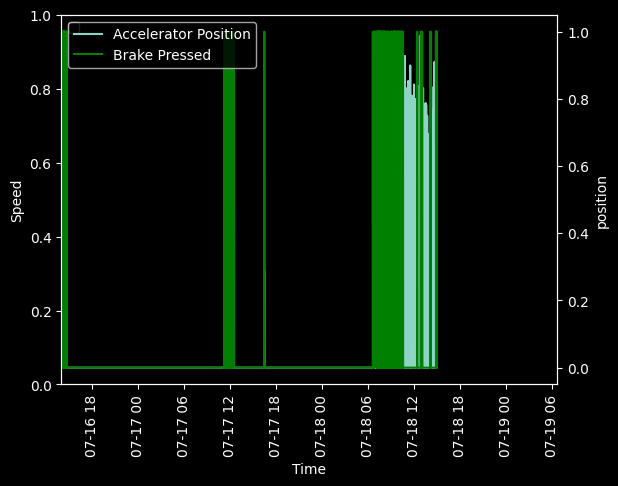

In [15]:
#plot relevant data

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(accel_position.datetime_x_axis, scaled_accel_position, label = "Accelerator Position")
plt.xlim(start_time, stop_time)
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")
plt.xlim(start_time, stop_time)
#ax1.plot(speed_kph.datetime_x_axis, speed_kph, color = 'red', label = "Speed KPH")


ax1.set_xlabel("Time")
ax1.set_ylabel("Speed")
ax_twin.set_ylabel("position")

ax1.tick_params("x", rotation  = 90)


plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

In [16]:
# in order to get position data, look up miguel's work for localization of fsgp data


# this project is essentially constrained in one lap


#from miguel's code, we find the number of laps done on one day, so let us

localisation code is primarily for day1 and day3 of fsgp.
- integrate the velocity curve up to a point and then manual mapping from distance covered to found coordinates.
- labs before and after we pitted will have nan values
- lap7 day1 - might have diverging velocities
- he dip happens after lap 28 and lap 32 which is when we pitted.
- used MDI vehicle velocity
-

In [17]:
reverse_coords = [
    [ 37.0011529 , -86.36837867],
    [ 37.00122817, -86.3682181 ],
    [ 37.00133071, -86.36801267],
    [ 37.00143614, -86.36779264],
    [ 37.00152389, -86.3675912 ],
    [ 37.00160574, -86.36740819],
    [ 37.00167596, -86.36725066],
    [ 37.00175285, -86.36709064],
    [ 37.00183166, -86.36691875],
    [ 37.00192538, -86.36670617],
    [ 37.00200136, -86.36653034],
    [ 37.00208623, -86.36635086],
    [ 37.00215644, -86.36619701],
    [ 37.00222549, -86.36603626],
    [ 37.00229839, -86.3658645 ],
    [ 37.00237732, -86.36569622],
    [ 37.00245038, -86.36553914],
    [ 37.00252912, -86.36537128],
    [ 37.00259904, -86.36521818],
    [ 37.00266755, -86.36507091],
    [ 37.00274639, -86.36490341],
    [ 37.00283342, -86.36471029],
    [ 37.00291248, -86.36454704],
    [ 37.00298517, -86.36439075],
    [ 37.0030636 , -86.36423803],
    [ 37.00313338, -86.36408574],
    [ 37.00320937, -86.36393701],
    [ 37.00330797, -86.36377724],
    [ 37.00343811, -86.36368662],
    [ 37.00357758, -86.36365019],
    [ 37.00372489, -86.36360692],
    [ 37.00388711, -86.36356354],
    [ 37.00405472, -86.36352621],
    [ 37.00423763, -86.36348621],
    [ 37.00437129, -86.36338074],
    [ 37.00448184, -86.36323899],
    [ 37.00457515, -86.36307953],
    [ 37.0047012 , -86.36286956],
    [ 37.00486024, -86.36273924],
    [ 37.00505061, -86.36270756],
    [ 37.00527945, -86.36272947],
    [ 37.00548802, -86.36263566],
    [ 37.00565341, -86.36245496],
    [ 37.00573513, -86.3621647 ],
    [ 37.00568611, -86.36182869],
    [ 37.00548782, -86.36157939],
    [ 37.0052881 , -86.36149696],
    [ 37.00511652, -86.36149669],
    [ 37.0049746 , -86.36158761],
    [ 37.00485989, -86.3616726 ],
    [ 37.00469955, -86.3617696 ],
    [ 37.00451492, -86.36178471],
    [ 37.00435852, -86.36173599],
    [ 37.00419576, -86.36162316],
    [ 37.00409127, -86.36146652],
    [ 37.00404463, -86.3612301 ],
    [ 37.00407232, -86.36097832],
    [ 37.00415922, -86.36078578],
    [ 37.00426711, -86.36066944],
    [ 37.00439509, -86.36060407],
    [ 37.00452844, -86.36057503],
    [ 37.00466778, -86.36054604],
    [ 37.004833  , -86.36050987],
    [ 37.00499495, -86.36047743],
    [ 37.00514229, -86.36044484],
    [ 37.00524902, -86.36041601],
    [ 37.00541074, -86.36037856],
    [ 37.00558676, -86.36034575],
    [ 37.00578957, -86.36038183],
    [ 37.00596102, -86.36045445],
    [ 37.00607154, -86.36065091],
    [ 37.0061651 , -86.36090615],
    [ 37.00626234, -86.3611639 ],
    [ 37.00637312, -86.36147776],
    [ 37.00642557, -86.36179897],
    [ 37.00644459, -86.36216748],
    [ 37.00637929, -86.36250433],
    [ 37.00629836, -86.36273906],
    [ 37.00622229, -86.36291634],
    [ 37.00611158, -86.36309997],
    [ 37.00600738, -86.36323379],
    [ 37.00589169, -86.3633461 ],
    [ 37.00576471, -86.36344689],
    [ 37.00564905, -86.36353398],
    [ 37.00551878, -86.36359932],
    [ 37.00537978, -86.36365448],
    [ 37.00525188, -86.36370605],
    [ 37.0051236 , -86.36376501],
    [ 37.00497727, -86.36382802],
    [ 37.00484855, -86.36391978],
    [ 37.00471266, -86.36403361],
    [ 37.0045783 , -86.36422396],
    [ 37.00447907, -86.36439954],
    [ 37.00435695, -86.36453807],
    [ 37.00424813, -86.36465022],
    [ 37.00411061, -86.36480228],
    [ 37.00397977, -86.36492984],
    [ 37.0038682 , -86.36504946],
    [ 37.00376295, -86.36516126],
    [ 37.00365436, -86.36527329],
    [ 37.00354759, -86.36539144],
    [ 37.00341675, -86.36552332],
    [ 37.00329206, -86.3656715 ],
    [ 37.00316095, -86.36581567],
    [ 37.00303256, -86.36594441],
    [ 37.00291203, -86.36607157],
    [ 37.00278014, -86.36622802],
    [ 37.00269333, -86.36641303],
    [ 37.00260606, -86.36659437],
    [ 37.00252845, -86.36675984],
    [ 37.00243487, -86.36695271],
    [ 37.00234795, -86.36716654],
    [ 37.00226102, -86.36735999],
    [ 37.00218046, -86.36754144],
    [ 37.00210026, -86.36771854],
    [ 37.00202358, -86.36787901],
    [ 37.00194406, -86.36806693],
    [ 37.00185835, -86.36825428],
    [ 37.00177578, -86.36843604],
    [ 37.00169902, -86.36860048],
    [ 37.0016732 , -86.3687928 ],
    [ 37.001679  , -86.3689974 ],
    [ 37.00168488, -86.36919051],
    [ 37.00169122, -86.36938766],
    [ 37.00169469, -86.3695562 ],
    [ 37.00170118, -86.36974238],
    [ 37.00171055, -86.36993991],
    [ 37.00167198, -86.37010864],
    [ 37.00158558, -86.37021273],
    [ 37.00148934, -86.37030898],
    [ 37.00139295, -86.37041757],
    [ 37.00129011, -86.37051816],
    [ 37.00120286, -86.37061913],
    [ 37.00112253, -86.37073184],
    [ 37.00106144, -86.37085264],
    [ 37.00099678, -86.37100197],
    [ 37.00092255, -86.37116696],
    [ 37.00083249, -86.37137665],
    [ 37.00073506, -86.37159438],
    [ 37.00065426, -86.37177611],
    [ 37.00057398, -86.37196168],
    [ 37.00060097, -86.37214635],
    [ 37.00074272, -86.37221467],
    [ 37.0009059 , -86.37222018],
    [ 37.00107657, -86.37218846],
    [ 37.00122503, -86.37211976],
    [ 37.00133803, -86.37204677],
    [ 37.00145467, -86.37192099],
    [ 37.00156457, -86.37178347],
    [ 37.00167114, -86.37162599],
    [ 37.00176434, -86.37145299],
    [ 37.00183833, -86.37126821],
    [ 37.00188646, -86.37112396],
    [ 37.0019441 , -86.37095574],
    [ 37.00197296, -86.370787  ],
    [ 37.00202945, -86.37067751],
    [ 37.00209668, -86.37048098],
    [ 37.00218305, -86.37031655],
    [ 37.00228558, -86.37016005],
    [ 37.00238818, -86.37002764],
    [ 37.00249377, -86.36991909],
    [ 37.00259639, -86.36983868],
    [ 37.00270864, -86.36976266],
    [ 37.00281411, -86.3697033 ],
    [ 37.00292264, -86.36964769],
    [ 37.00303847, -86.369599  ],
    [ 37.00316942, -86.36952703],
    [ 37.00332578, -86.36939126],
    [ 37.00342743, -86.36921198],
    [ 37.00346211, -86.36901195],
    [ 37.00343231, -86.36879509],
    [ 37.00336736, -86.36861758],
    [ 37.00327983, -86.36847602],
    [ 37.00316589, -86.36828932],
    [ 37.00305696, -86.36810259],
    [ 37.00296937, -86.36793662],
    [ 37.00293802, -86.36773416],
    [ 37.00295792, -86.36753614],
    [ 37.00301643, -86.36739089],
    [ 37.00307192, -86.36724611],
    [ 37.00312788, -86.36711056],
    [ 37.00320856, -86.36698638],
    [ 37.00331523, -86.36684361],
    [ 37.00340519, -86.36672019],
    [ 37.00350264, -86.36658791],
    [ 37.00361135, -86.36649982],
    [ 37.00374245, -86.36645177],
    [ 37.00387034, -86.3664758 ],
    [ 37.00395668, -86.36655587],
    [ 37.00402368, -86.36670753],
    [ 37.00407807, -86.36686779],
    [ 37.00412607, -86.36701603],
    [ 37.00418686, -86.36718831],
    [ 37.00427315, -86.36742386],
    [ 37.00436296, -86.3676927 ],
    [ 37.00442144, -86.36790543],
    [ 37.00445858, -86.36815496],
    [ 37.00447715, -86.36847342],
    [ 37.00444541, -86.36882644],
    [ 37.00434238, -86.36911386],
    [ 37.00425654, -86.36927291],
    [ 37.00418289, -86.36939303],
    [ 37.00410293, -86.36950912],
    [ 37.00399731, -86.36962489],
    [ 37.00390147, -86.36973254],
    [ 37.00379293, -86.36984054],
    [ 37.00369701, -86.36994104],
    [ 37.00359474, -86.37004514],
    [ 37.0034838 , -86.3701598 ],
    [ 37.00338477, -86.37024376],
    [ 37.00327609, -86.37032788],
    [ 37.00318982, -86.37040789],
    [ 37.00306205, -86.37049992],
    [ 37.00294389, -86.37059192],
    [ 37.00283177, -86.37070006],
    [ 37.00272312, -86.37083897],
    [ 37.00264003, -86.37094293],
    [ 37.00255683, -86.37103895],
    [ 37.00249914, -86.37115127],
    [ 37.00243497, -86.37126771],
    [ 37.00236746, -86.3713964 ],
    [ 37.00230001, -86.37152106],
    [ 37.00223561, -86.37164596],
    [ 37.00217132, -86.37175865],
    [ 37.0021135 , -86.37187932],
    [ 37.00204601, -86.37200003],
    [ 37.00196791, -86.37211434],
    [ 37.00188761, -86.3722312 ],
    [ 37.00180726, -86.37233202],
    [ 37.00173651, -86.37241676],
    [ 37.00165284, -86.37250555],
    [ 37.00155067, -86.3726109 ],
    [ 37.00144762, -86.37271211],
    [ 37.00136704, -86.37279282],
    [ 37.00126713, -86.37288565],
    [ 37.00115123, -86.37299929],
    [ 37.00103518, -86.37310829],
    [ 37.0009191 , -86.37321738],
    [ 37.00082561, -86.37329809],
    [ 37.00072863, -86.37339546],
    [ 37.00061364, -86.37350099],
    [ 37.00051698, -86.37360214],
    [ 37.00042667, -86.37368311],
    [ 37.00032338, -86.37378434],
    [ 37.00022342, -86.37387665],
    [ 37.00012018, -86.3739737 ],
    [ 37.00002051, -86.37405916],
    [ 36.99991404, -86.37415222],
    [ 36.99981076, -86.37423248],
    [ 36.99970432, -86.37430523],
    [ 36.99958169, -86.37432571],
    [ 36.99946928, -86.37430399],
    [ 36.99934964, -86.37428072],
    [ 36.99922365, -86.37425686],
    [ 36.99908793, -86.37422888],
    [ 36.99899069, -86.37413638],
    [ 36.99896465, -86.37397888],
    [ 36.9989808 , -86.37380904],
    [ 36.99900664, -86.37362303],
    [ 36.99904589, -86.37342887],
    [ 36.9990885 , -86.37323096],
    [ 36.99912743, -86.3730292 ],
    [ 36.99916641, -86.37284378],
    [ 36.99921127, -86.37261758],
    [ 36.99924349, -86.37245211],
    [ 36.99932082, -86.37230251],
    [ 36.99932082, -86.37230251],
    [ 36.99940337, -86.37214797],
    [ 36.99948814, -86.37199725],
    [ 36.99958754, -86.37189043],
    [ 36.99970528, -86.37178738],
    [ 36.99982625, -86.37169183],
    [ 36.99997073, -86.37159181],
    [ 37.00011471, -86.3714889 ],
    [ 37.00027357, -86.37138907],
    [ 37.0003852 , -86.37123775],
    [ 37.00042033, -86.37099884],
    [ 37.00038811, -86.3707825 ],
    [ 37.00031195, -86.37062837],
    [ 37.00026491, -86.37041498],
    [ 37.00030254, -86.37020247],
    [ 37.00038472, -86.3700261 ],
    [ 37.0004699 , -86.36984594],
    [ 37.00056383, -86.36964375],
    [ 37.00064015, -86.3694857 ],
    [ 37.00070993, -86.36934481],
    [ 37.0008098 , -86.36912411],
    [ 37.00090662, -86.36891836],
    [ 37.00098578, -86.36874579],
    [ 37.00107373, -86.36854755]
  ]

coords = reverse_coords[::-1] # coordinates in the correct order; starting coordinate goes first

In [18]:
from data_tools import lap_tools
from physics.environment.gis.gis import GIS
from physics.environment.gis.gis import calculate_path_distances

# Defining dictionary "route_data"

route_data = {
    "path" : np.array(coords),
    "elevations" : np.zeros(len(coords)),
    "time_zones" : np.zeros(len(coords)),
    "num_unique_coords" : (len(coords) - 1) }

# Creating GIS object

starting_coords = [37.00107373, -86.36854755]

gis = GIS(route_data, starting_coords, current_coord = starting_coords)

lap_length = np.cumsum(calculate_path_distances(gis.path[:gis.num_unique_coords]))[-1] # TOTAL LAP LENGTH

/Users/joshuariefman/Solar/data_analysis/array_temp/.venv/lib/python3.13/site-packages/filterpy/common/helpers.py:367: SyntaxWarning: invalid escape sequence '\S'
  P = \Sum {A[i] B[i].T} for i in 0..N


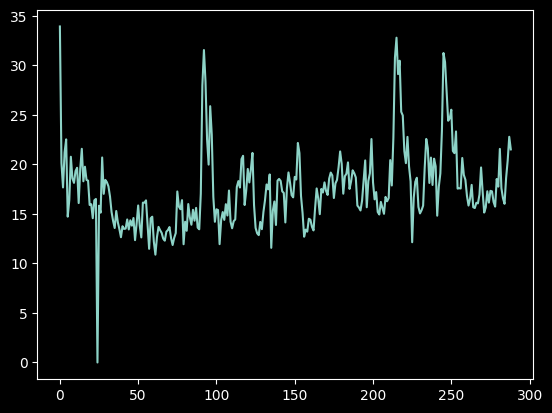

In [19]:
plt.plot(calculate_path_distances(gis.path[:gis.num_unique_coords]))

# Obtain the distance between each coordinate by approximating the spline between them
#     as a straight line, and use the Haversine formula (https://en.wikipedia.org/wiki/Haversine_formula)
#     to calculate distance between coordinates on a sphere.


 """
        Given the original, lap-averaged `speeds_kmh` and an array of speed deviations in km/h for each track index,
        compute the position and actual speed as simulation-time arrays.

        :param speeds_kmh: Lap-averaged speeds in km/h.
        :param track_speeds: A speed deviation in km/h for each track index. Expects the mean to be at 0.
        :param dt:
        :return:
        """

so, to actually compute the position, we are using the calculate_speeds_and_position from physics_rs
but this is still not time aligned.

In [20]:
calculated_position = gis.calculate_closest_gis_indices(speed_kph / 3.6 * 0.1)

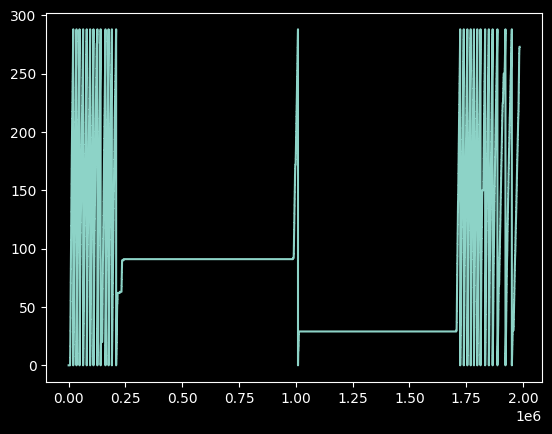

In [21]:
plt.plot(calculated_position)

In [22]:
import math

def calculate_circular_track_curvature(coords, step=1):
    """
    Calculates curvature for a CLOSED LOOP (circular) race track.

    :param coords: List of tuples [(lat, lon), ...] assumed to be in order.
    :param step: The smoothing stride (1=sensitive, 5=smooth).
    :return: List of radii in meters.
    """

    if not coords:
        return []

    # 1. Convert Lat/Lon to Local X/Y (Meters)
    # We use the first point as the reference center for projection
    center_lat = coords[0][0]

    # Calculate conversion factors based on the track's latitude
    meters_per_deg_lat = 111132.954 - 559.822 * math.cos(2 * math.radians(center_lat))
    meters_per_deg_lon = 111412.84 * math.cos(math.radians(center_lat))

    xy_points = []
    for lat, lon in coords:
        y = lat * meters_per_deg_lat
        x = lon * meters_per_deg_lon
        xy_points.append((x, y))

    radii = []
    n = len(xy_points)

    # 2. Calculate Radius with Wrap-Around Indexing
    for i in range(n):
        # Use modulo (%) to wrap around the start/finish line
        # If i=0 and step=1, the "previous" point becomes the last point in the list
        p1 = xy_points[(i - step) % n]
        p2 = xy_points[i]
        p3 = xy_points[(i + step) % n]

        # Calculate side lengths (Euclidean distance)
        a = math.dist(p1, p2)
        b = math.dist(p2, p3)
        c = math.dist(p3, p1)

        # Shoelace formula for Area of the triangle
        area = 0.5 * (p1[0]*(p2[1] - p3[1]) +
                         p2[0]*(p3[1] - p1[1]) +
                         p3[0]*(p1[1] - p2[1]))

        # Calculate Radius (R = abc / 4A)
        if  -1e-6 < area < 1e-6:
            radii.append(0) # Straight line
        else:
            R = (a * b * c) / (4 * area)
            #if R > 10000:
              #  R = 0
            radii.append(1/R)


    return radii

radius_of_curvature = calculate_circular_track_curvature(coords, step=2)

In [23]:
calculated_position.shape

(1985282,)

In [24]:
speed_kph_df = pd.DataFrame(speed_kph).sort_index()
calculated_position_df = pd.DataFrame(calculated_position).sort_index()
calculated_roc = [radius_of_curvature[i] for i in calculated_position]
calculated_roc_df = pd.DataFrame(calculated_roc).sort_index()

merged_df = pd.merge_asof(
    speed_kph_df,
    calculated_roc_df,
    left_index=True,
    right_index=True,
    direction='nearest'
)

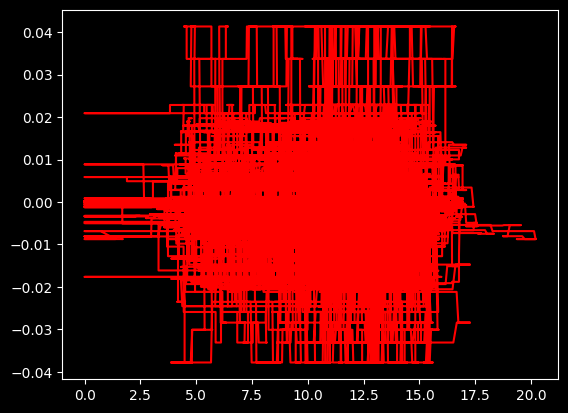

In [25]:
#plt.plot(merged_df['0_y'])
plt.plot(merged_df['0_x'],merged_df['0_y'], color = 'red')

NameError: name 'calculated_speeds' is not defined

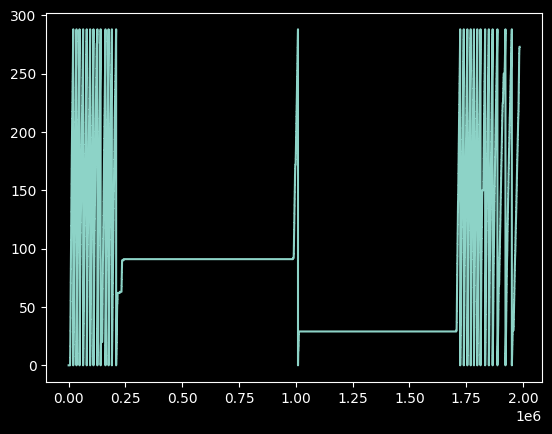

In [26]:
plt.plot(calculated_position)
plt.plot(calculated_speeds, color = 'red') # this seems not right.

In [27]:
#how do i align this with time?

In [28]:
len(calculated_position)

1985282

In [29]:
#preprocessing - convert everything to pandas dataframes.


df_mech_brake_pressed = pd.DataFrame(mech_brake_pressed)
df_accel_position = pd.DataFrame(scaled_accel_position)
#df_speed_kph = pd.DataFrame(speed_kph)




In [30]:
# combine all dfs and resample, then feed to scaler.
# states = velocity, position
# control = mbrake pressed, accelerator position
def combine_dfs(telemetry_names, index_common, all_dfs):
        combined_df = pd.DataFrame(index=index_common)

        for name, df in zip(telemetry_names, all_dfs):
            #df_interp = self.resample(df, index_common)
            combined_df[name] = df

        return combined_df


In [31]:

all_dfs = [df_mech_brake_pressed, df_accel_position]
combined_df = combine_dfs(["mech_brake_pressed", "accel_position"], df_mech_brake_pressed.index, all_dfs)


In [32]:
final_df = pd.concat([combined_df, merged_df], axis = 1)

In [33]:
final_df.head()

,mech_brake_pressed,accel_position,0_x,0_y
0,0.0,0.0,0.0,-0.000474
1,0.0,0.0,0.0,-0.000474
2,0.0,0.0,0.0,-0.000474
3,0.0,0.0,0.0,-0.000474
4,0.0,0.0,0.0,-0.000474


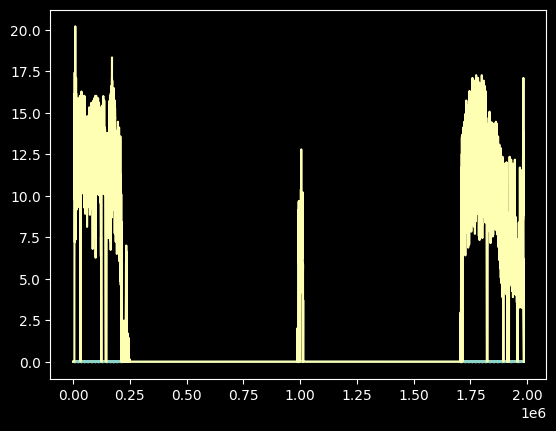

In [34]:
plt.plot(final_df["0_y"])
plt.plot(final_df["0_x"])

In [35]:
# i dont really think there is much of a need to resample right now, because on querying from influx they will all be at the same frequency - granularity is 0.1s.
# preprocessing pipeline: dataset - rescaling - sequences - tensors - RNN

In [36]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from RNN_Dataset import RNN_Dataset


def make_sequence_datasets(
    df_xy,
    state_cols,
    control_cols,
    seq_len,
    stride=100,
    train_frac=0.8,
    batch_size=64,
):


    cols_to_scale = state_cols + control_cols

    # Train/test split (time-series safe)
    n_total = len(df_xy)
    train_len = int(train_frac * n_total)
    df_xy = df_xy.dropna(subset=state_cols + control_cols).reset_index(drop=True)

    df_train_raw = df_xy.iloc[:train_len].reset_index(drop=True)
    df_test_raw  = df_xy.iloc[train_len:].reset_index(drop=True)

    # Fit scaler ONLY on training data
    scaler = StandardScaler()
    scaler.fit(df_train_raw[cols_to_scale])

    # Apply scaling
    df_train = df_train_raw.copy()
    df_test  = df_test_raw.copy()
    df_train.dropna()
    df_test = df_test.dropna()

    df_train[cols_to_scale] = scaler.transform(df_train_raw[cols_to_scale])
    df_test[cols_to_scale]  = scaler.transform(df_test_raw[cols_to_scale])

    # Create datasets
    train_dataset = RNN_Dataset(
        df_train,
        state_cols,
        control_cols,
        seq_len,
        stride
    )

    test_dataset = RNN_Dataset(
        df_test,
        state_cols,
        control_cols,
        seq_len,
        stride
    )

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_dataset, test_dataset, train_loader, test_loader, scaler


In [37]:
import DataPreprocessing
train_dataset, test_dataset, train_loader, test_loader, scaler = DataPreprocessing.make_sequence_datasets(final_df, state_cols = ['0_x', '0_y'], control_cols = ['mech_brake_pressed', 'accel_position'], seq_len = 100, train_frac=0.7, batch_size = 64)

so we are feeding a certain "seq" worth of data into the RNN. This includes the controls and state ( brake, accel pos, speed and position). when we are using the model, we feed in the last n seconds of these inputs. the model then outputs the exact control that the driver will be using next.
this does not make sense

what we really want to do is given an optimised speed and position input, this would probably be a singular point
we want the RNN to predict the steps to reach there - or at the least atleast a timestep before this predicted control, as otherwise this would not be useful for the driver.
what would be more useful for the driver is to probably give them the change in these controls over this given sequence of time.
so what the model really takes in would be the current state and control at this given time, then we give them a future "state" - position and time, and we want to tell the driver how they reach these optimised speed.
the inverse model maps the given state to controls. this can be done by preliminary RNN.

so, is our model predicting a list of controls from current state to optimised state
this means we might need to predict the states trajectory up to this optimised state, maybe indirectly? this needs a defined sequence. granularity of current data is 0.1 seconds. we would need at least 1 second to see meaningful change, so a seq length of 10 is feasible.
further, does the model evaluate if this state is physcially possible. more ver if the given state oc control changes is physcially feasible.

Input: Current state + target state (position, speed, time)+ current controls for context
Output: Sequence of control changes to reach the target





realised that brake pressed although told to be continous is actually not (either 0 or 1). this makes it harder for the rnn to truly capture they dynamics.

In [38]:

from RNN import *
state   = ["0_x", "0_y"]
control = ["mech_brake_pressed", "accel_position"]
seq_length = 100
input_size = len(state)
output_size = len(control)


hidden_size = 64     # was 256
num_layers  = 2
model = RNN(input_size, hidden_size, num_layers, seq_length, output_size).to(device)

In [39]:
# now we define the training loop. we are pretending a trajectory of controls.

#build the model


def train_model(model, train_loader, test_loader, epochs):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    train_losses = []
    test_losses = []
    print("NaNs in Train Loader:", any(torch.isnan(x).any() for x, y in train_loader))
    print("NaNs in Test Loader:", any(torch.isnan(x).any() for x, y in test_loader))
    for epoch in range(epochs):

        #training loop
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad() #resets the gradients to zero

            outputs = model(x_batch)

            if torch.isnan(outputs).any():
                print("NaN in model outputs")
                print("x_batch min/max:", x_batch.min().item(), x_batch.max().item())
                break

            loss = criterion(outputs, y_batch)

            if torch.isnan(loss):
                print("NaN in loss")
                print("outputs min/max:", outputs.min().item(), outputs.max().item())
                print("y_batch min/max:", y_batch.min().item(), y_batch.max().item())
                break
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()

            train_loss += loss.item() #convert tensor to float
        train_loss/=len(train_loader) #average losses over batches
        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")
        train_losses.append(train_loss)

        # testing loop
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                optimizer.zero_grad()
                predictions = model(x_batch)
                loss = criterion(predictions, y_batch)
                test_loss += loss.item()
        test_loss/=len(test_loader)
        test_losses.append(test_loss)

    return train_losses, test_losses

In [40]:
train_model(model, train_loader, test_loader, epochs = 45)

NaNs in Train Loader: False
NaNs in Test Loader: False
Epoch 1/45, Train Loss: 0.7229
Epoch 2/45, Train Loss: 0.6970
Epoch 3/45, Train Loss: 0.6939
Epoch 4/45, Train Loss: 0.6917
Epoch 5/45, Train Loss: 0.6891
Epoch 6/45, Train Loss: 0.6874
Epoch 7/45, Train Loss: 0.6878
Epoch 8/45, Train Loss: 0.6855
Epoch 9/45, Train Loss: 0.6841
Epoch 10/45, Train Loss: 0.6831
Epoch 11/45, Train Loss: 0.6793
Epoch 12/45, Train Loss: 0.6790
Epoch 13/45, Train Loss: 0.6697
Epoch 14/45, Train Loss: 0.6562
Epoch 15/45, Train Loss: 0.6499
Epoch 16/45, Train Loss: 0.6431
Epoch 17/45, Train Loss: 0.6354
Epoch 18/45, Train Loss: 0.6301
Epoch 19/45, Train Loss: 0.6269
Epoch 20/45, Train Loss: 0.6531
Epoch 21/45, Train Loss: 0.6206
Epoch 22/45, Train Loss: 0.6182
Epoch 23/45, Train Loss: 0.6169
Epoch 24/45, Train Loss: 0.6159
Epoch 25/45, Train Loss: 0.6245
Epoch 26/45, Train Loss: 0.6090
Epoch 27/45, Train Loss: 0.6073
Epoch 28/45, Train Loss: 0.6055
Epoch 29/45, Train Loss: 0.6040
Epoch 30/45, Train Loss: 0

([0.7229045986185246,
  0.6969987947948918,
  0.6938816462032396,
  0.6917116838334575,
  0.6890652813185933,
  0.687386237358784,
  0.687838067633534,
  0.6855159446394821,
  0.6841054431697969,
  0.6830816473137604,
  0.6792766635740235,
  0.6790290286730789,
  0.6696864965022015,
  0.6561945695577535,
  0.6498647094851705,
  0.6430561109993826,
  0.6354320552579351,
  0.6301253590968804,
  0.6268755746668213,
  0.6531070826819579,
  0.6206222825338095,
  0.6181958254502572,
  0.6168603179765637,
  0.6158720482461053,
  0.6245002601278853,
  0.6090160244317279,
  0.6072647734060547,
  0.6054727331275853,
  0.6040067405216565,
  0.6038530013814771,
  0.6026376283209248,
  0.6030337170980096,
  0.5978542966473156,
  0.5974570837238492,
  0.5959470767308684,
  0.5961993796860471,
  0.5953714718106645,
  0.5928848996712106,
  0.5933751030340454,
  0.6135935223075599,
  0.5905653304374057,
  0.5922027139911824,
  0.5906603070675518,
  0.5875394189292017,
  0.609298004419016],
 [0.85603999

In [41]:
# inverse transform requires dummy array of full feature width
def inverse_scale_controls(scaler, control_array, state_cols, control_cols):
    n_states = len(state_cols)
    dummy = np.zeros((len(control_array), len(state_cols) + len(control_cols)))
    dummy[:, n_states:] = control_array
    return scaler.inverse_transform(dummy)[:, n_states:]


In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_control_trajectory(model, test_dataset, scaler, state_cols, control_cols, sample_idx):
    model.eval()
    x_input, y_target = test_dataset[sample_idx]

# x_input should be [seq_len, n_states]
    print(x_input.shape)  # confirm this first

    x_np = x_input.numpy()  # [seq_len, n_states]

    # derive time axes from actual array shapes, not seq_len variable
    time_controls = np.arange(y_target.shape[0]) * 0.1
    time_states   = np.arange(x_np.shape[0]) * 0.1
    x_input, y_target = test_dataset[sample_idx]

    with torch.no_grad():
        device = next(model.parameters()).device
        x_tensor = x_input.to(device).unsqueeze(0)
        y_pred = model(x_tensor).squeeze(0).cpu().numpy()

    y_target = y_target.numpy()
    x_np = x_input.numpy()  # [seq_len, n_states]

    # inverse transform controls
    # scaler was fit on state_cols + control_cols so controls start at index n_states
    n_states = len(state_cols)
    n_controls = len(control_cols)
    seq_len = y_target.shape[0]
    def unscale_states(arr):
        state_mean = scaler.mean_[:n_states]
        state_std  = scaler.scale_[:n_states]
        return arr * state_std + state_mean
    def unscale_controls(arr):
        # arr: [seq_len, n_controls]
        dummy = np.zeros((seq_len, n_states + n_controls))
        dummy[:, n_states:] = arr
        return scaler.inverse_transform(dummy)[:, n_states:]



    y_target_unscaled = unscale_controls(y_target)
    y_pred_unscaled   = unscale_controls(y_pred)
    x_unscaled        = unscale_states(x_np)

    time_controls = np.arange(seq_len) * 0.1
    time_states   = np.arange(x_np.shape[0]) * 0.1

    # plot controls
    fig, axes = plt.subplots(n_controls, 1, figsize=(10, 4 * n_controls), sharex=True)
    if n_controls == 1:
        axes = [axes]

    for i, col in enumerate(control_cols):
        axes[i].plot(time_controls, y_target_unscaled[:, i], 'g-', label='Actual (Driver)')
        axes[i].plot(time_controls, y_pred_unscaled[:, i], 'r--', label='Predicted (RNN)')
        axes[i].set_ylabel(col)
        axes[i].legend()
        axes[i].grid(True)

    axes[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Control Trajectory — Sample {sample_idx}")
    plt.tight_layout()

    # plot states
    fig2, axes2 = plt.subplots(n_states, 1, figsize=(10, 4 * n_states), sharex=True)
    if n_states == 1:
        axes2 = [axes2]
    print(x_np.shape)        # should be [seq_len, n_states]
    print(x_unscaled.shape)  # should match
    print(time_states.shape)
    for i, col in enumerate(state_cols):
        axes2[i].plot(time_states, x_unscaled[:, i], 'b-', label=col)
        axes2[i].set_ylabel(col)
        axes2[i].legend()
        axes2[i].grid(True)

    axes2[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Input State Sequence — Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

In [43]:
# find a sample with nonzero controls
for i in range(len(test_dataset)):
    x, y = test_dataset[i]
    if y.abs().mean() > 0.1:
        print(f"sample {i} has nonzero controls")
        break

sample 0 has nonzero controls


In [44]:
for i in range(len(test_dataset)):
    x, y = test_dataset[i]
    if y.abs().mean() >= 0.88:
        print(f"use sample_idx={i}")
        break

use sample_idx=3004


torch.Size([100, 2])
(100, 2)
(100, 2)
(100,)


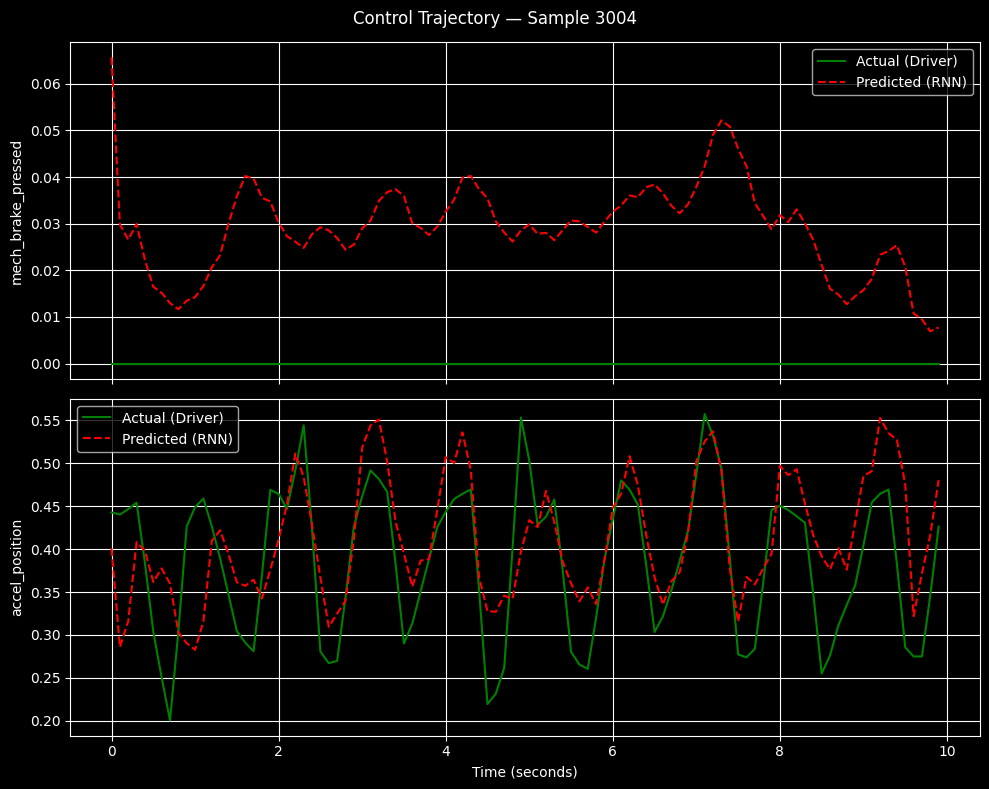

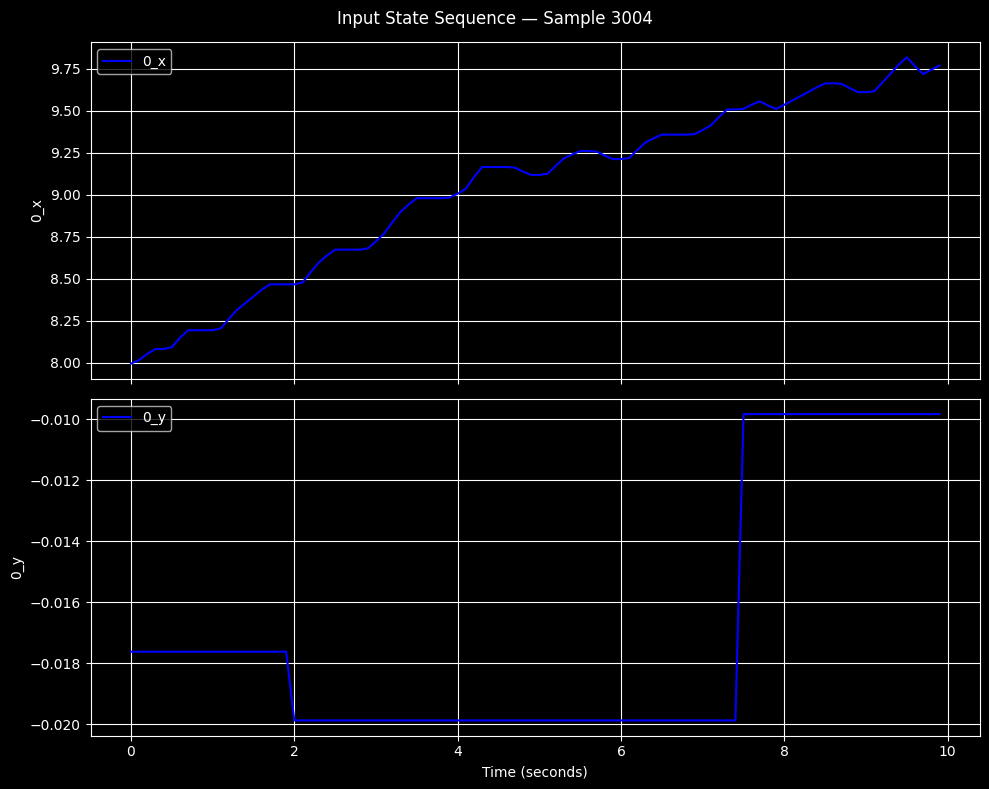

torch.Size([100, 2])
(100, 2)
(100, 2)
(100,)


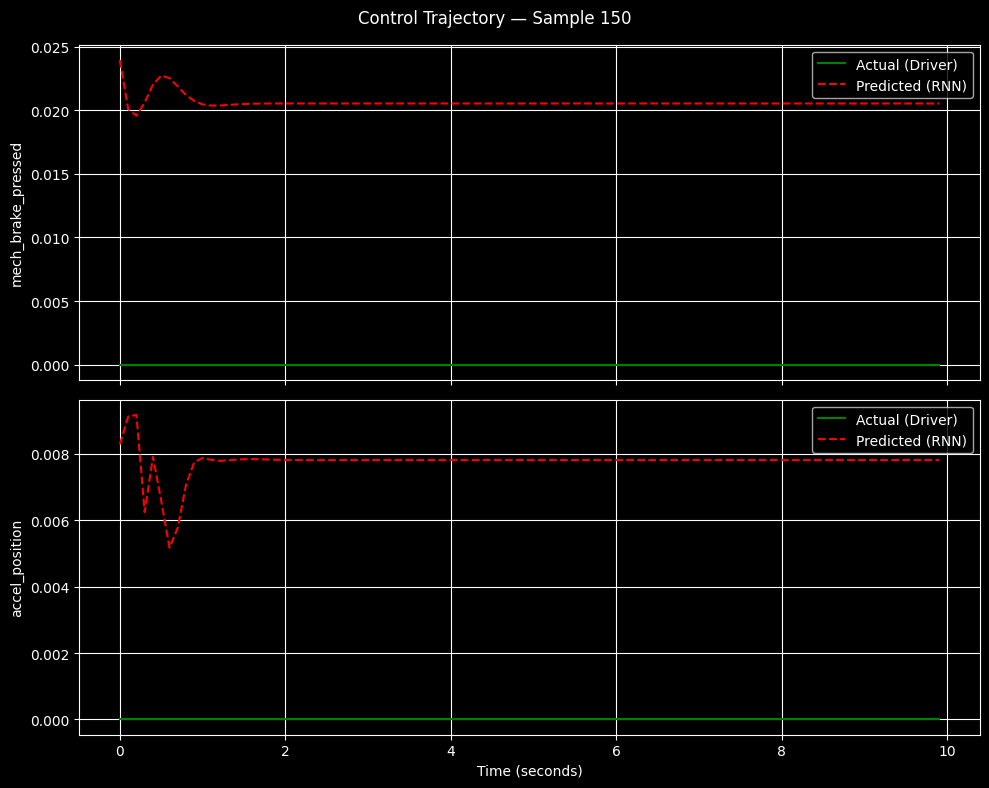

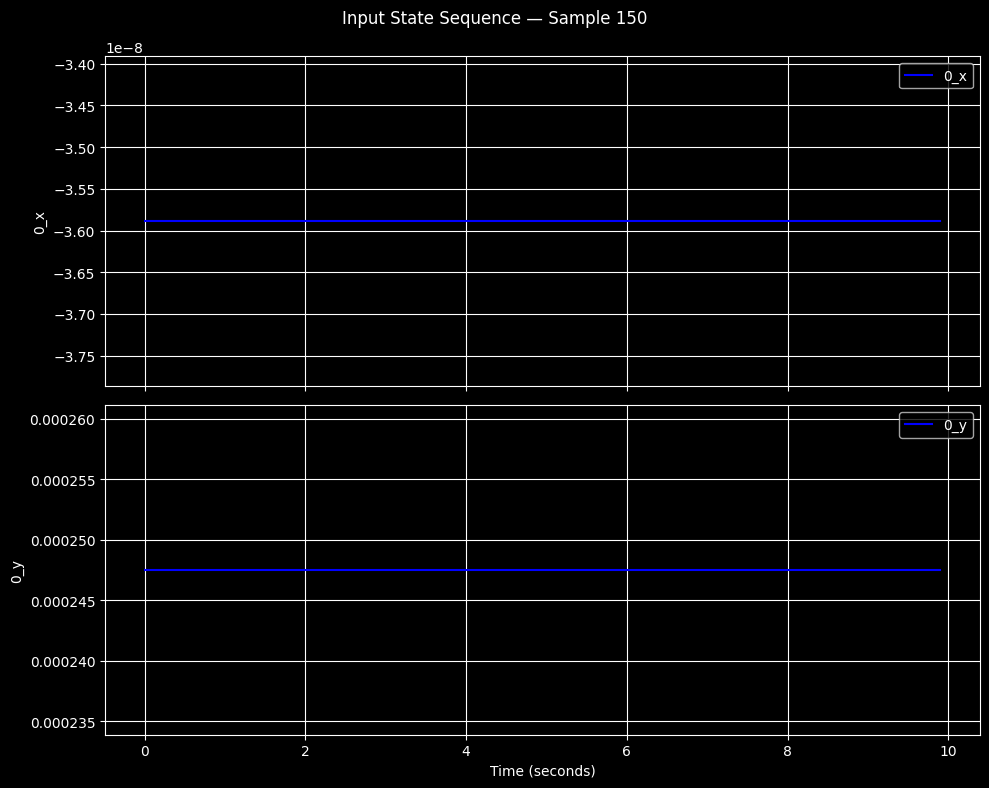

In [45]:
state_cols = ['0_x', '0_y']
control_cols = ['mech_brake_pressed', 'accel_position']
plot_control_trajectory(model, test_dataset, scaler, state_cols, control_cols, sample_idx=3004)
plot_control_trajectory(model, test_dataset, scaler, state_cols, control_cols, sample_idx=150)

In [543]:
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend()
plt.show()

NameError: name 'train_losses' is not defined

In [544]:
x, y = test_dataset[10]
print(y)  # should not be all zeros

tensor([[-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1.0961],
        [-0.3674, -1

In [545]:
def plot_control_trajectory_extended(model, test_dataset, scaler, state_cols, control_cols, n_samples=10, start_idx=0):
    model.eval()
    device = next(model.parameters()).device

    all_states   = []
    all_y_true   = []
    all_y_pred   = []

    n_states   = len(state_cols)
    n_controls = len(control_cols)

    def unscale_controls(arr):
        n = arr.shape[0]
        dummy = np.zeros((n, n_states + n_controls))
        dummy[:, n_states:] = arr
        return scaler.inverse_transform(dummy)[:, n_states:]

    def unscale_states(arr):
        n = arr.shape[0]
        dummy = np.zeros((n, n_states + n_controls))
        dummy[:, :n_states] = arr
        return scaler.inverse_transform(dummy)[:, :n_states]

    for i in range(start_idx, start_idx + n_samples):
        x_input, y_target = test_dataset[i]

        with torch.no_grad():
            x_tensor = x_input.unsqueeze(0).to(device)
            y_pred = model(x_tensor).squeeze(0).cpu().numpy()

        all_states.append(x_input.numpy())
        all_y_true.append(y_target.numpy())
        all_y_pred.append(y_pred)

    # concatenate along time axis
    all_states = np.concatenate(all_states, axis=0)
    all_y_true = np.concatenate(all_y_true, axis=0)
    all_y_pred = np.concatenate(all_y_pred, axis=0)

    all_states = unscale_states(all_states)
    all_y_true = unscale_controls(all_y_true)
    all_y_pred = unscale_controls(all_y_pred)

    time_axis = np.arange(len(all_y_true)) * 0.1

    # plot controls
    fig, axes = plt.subplots(n_controls, 1, figsize=(14, 4 * n_controls), sharex=True)
    if n_controls == 1:
        axes = [axes]

    for i, col in enumerate(control_cols):
        axes[i].plot(time_axis, all_y_true[:, i], 'g-', label='Actual', linewidth=1)
        axes[i].plot(time_axis, all_y_pred[:, i], 'r--', label='Predicted', linewidth=1)
        axes[i].set_ylabel(col)
        axes[i].legend()
        axes[i].grid(True)

    axes[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Control Trajectory — {n_samples} consecutive samples")
    plt.tight_layout()

    # plot states
    time_states = np.arange(len(all_states)) * 0.1
    fig2, axes2 = plt.subplots(n_states, 1, figsize=(14, 4 * n_states), sharex=True)
    if n_states == 1:
        axes2 = [axes2]

    for i, col in enumerate(state_cols):
        axes2[i].plot(time_states, all_states[:, i], 'b-', label=col, linewidth=1)
        axes2[i].set_ylabel(col)
        axes2[i].legend()
        axes2[i].grid(True)

    axes2[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Input State Sequence — {n_samples} consecutive samples")
    plt.tight_layout()
    plt.show()

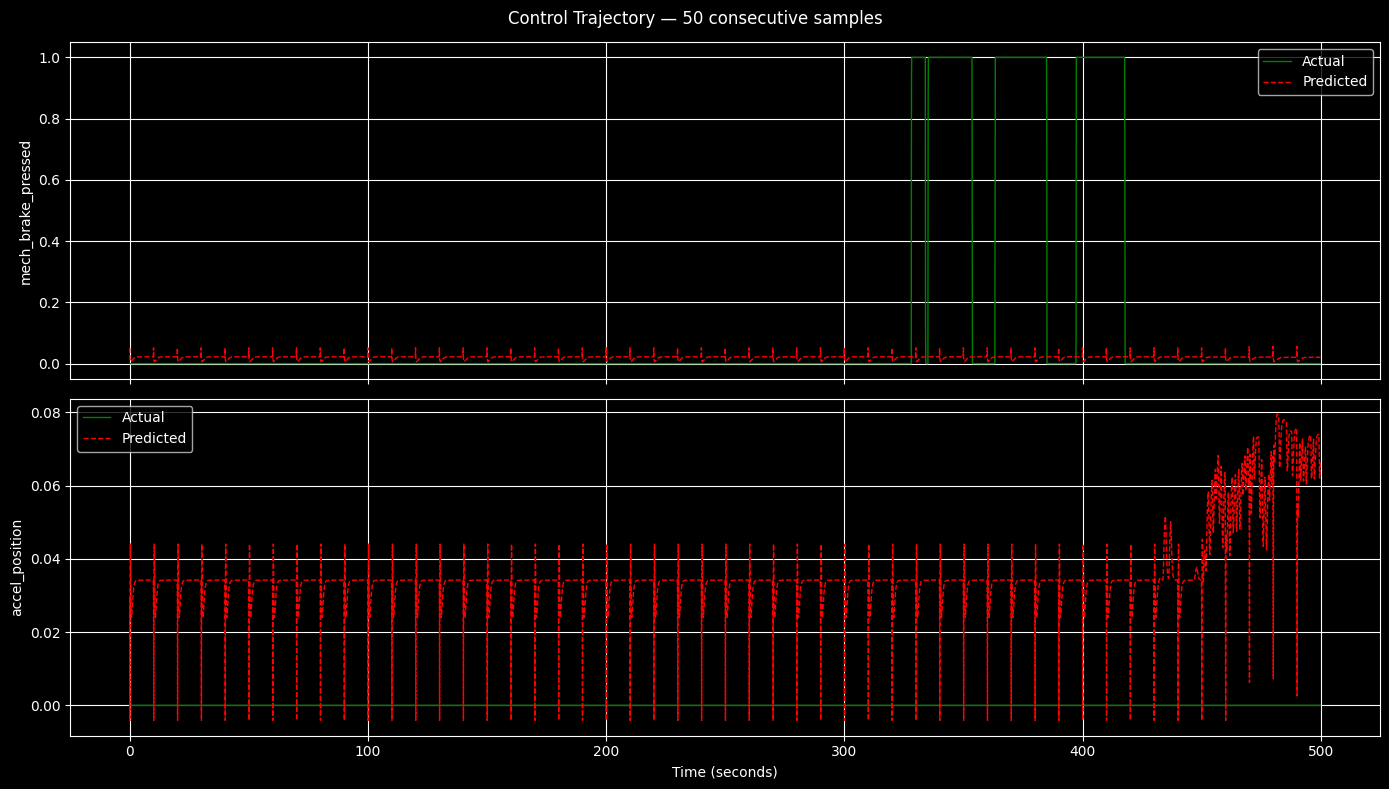

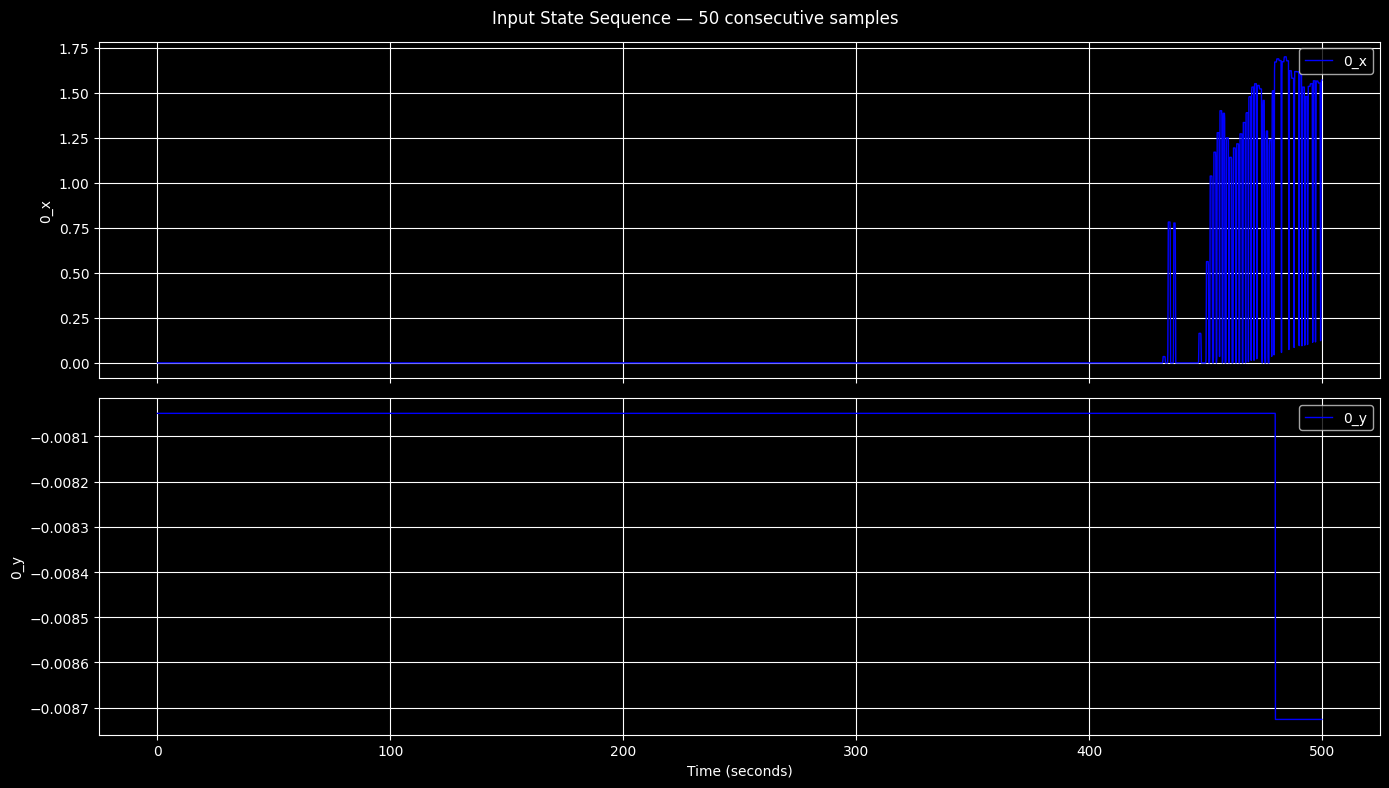

In [546]:
plot_control_trajectory_extended(model, test_dataset, scaler, state_cols, control_cols, n_samples=50, start_idx=0)

In [547]:
import seaborn as sns

def plot_error_heatmap(model, loader, device):
    all_errors = []
    all_speeds = []
    all_targets = []

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in loader:
            preds = model(x_batch.to(device)).cpu()
            # Calculate Mean Absolute Error for the whole 10-step sequence
            error = torch.mean(torch.abs(preds - y_batch), dim=(1, 2))

            # Extract Current Speed and Target Speed from x_batch
            # Assuming Speed is index 0 and Target Speed is index 2 in your cat()
            speeds = x_batch[:, 0]
            targets = x_batch[:, 2]

            all_errors.extend(error.numpy())
            all_speeds.extend(speeds.numpy())
            all_targets.extend(targets.numpy())

    # Create a DataFrame for plotting
    import pandas as pd
    df_err = pd.DataFrame({'Current Speed': all_speeds, 'Target Speed': all_targets, 'MAE': all_errors})

    # Pivot for heatmap (binning speeds)
    df_err['Speed Bin'] = pd.cut(df_err['Current Speed'], bins=10)
    df_err['Target Bin'] = pd.cut(df_err['Target Speed'], bins=10)
    pivot_table = df_err.pivot_table(index='Speed Bin', columns='Target Bin', values='MAE', aggfunc='mean')

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, cmap='YlOrRd')
    plt.title("Control Prediction Error (MAE) across State Space")
    plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
plot_error_heatmap(model, test_loader, device)

Absolute Error Average: 0.11585489047996239


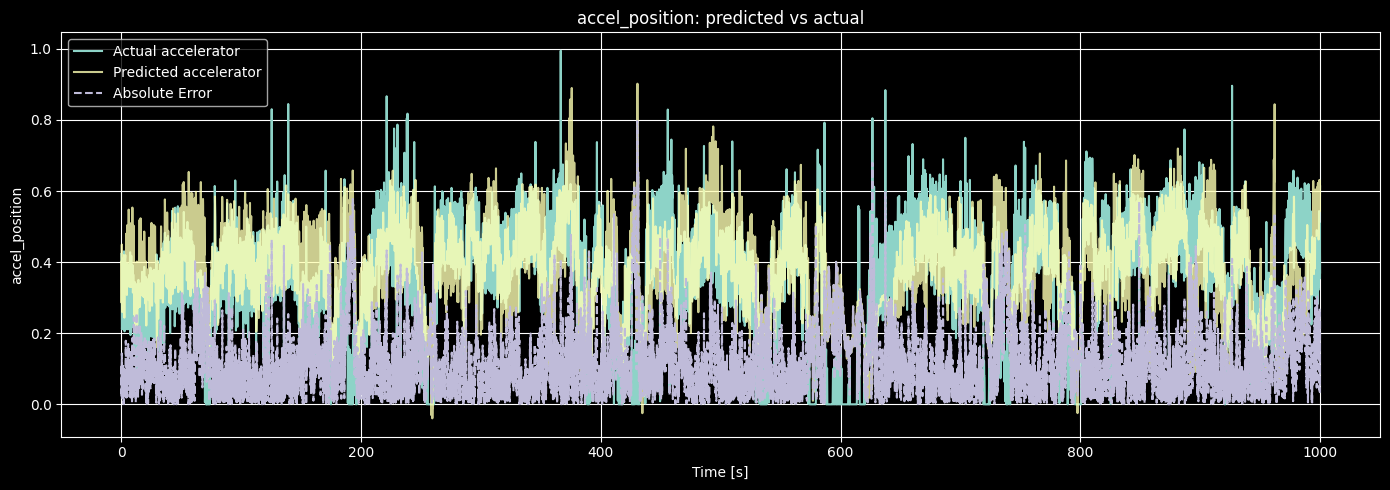

In [46]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_long_accel_sequence(
    model,
    dataset,
    scaler,
    state_cols,
    control_cols,
    accel_col="accel_position",
    start_idx=0,
    n_samples=50,
    dt=0.1,
):
    model.eval()
    device = next(model.parameters()).device

    n_states = len(state_cols)
    n_controls = len(control_cols)
    accel_idx = control_cols.index(accel_col)

    def unscale_controls(arr):
        # arr shape: [N, n_controls]
        dummy = np.zeros((arr.shape[0], n_states + n_controls))
        dummy[:, n_states:] = arr
        return scaler.inverse_transform(dummy)[:, n_states:]

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for i in range(start_idx, min(start_idx + n_samples, len(dataset))):
            x_seq, y_seq = dataset[i]

            x_in = x_seq.unsqueeze(0).to(device)              # [1, seq_len, n_states]
            y_pred = model(x_in).squeeze(0).cpu().numpy()    # [seq_len, n_controls]
            y_true = y_seq.numpy()                           # [seq_len, n_controls]

            y_true_all.append(y_true)
            y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_pred_all = np.concatenate(y_pred_all, axis=0)

    y_true_unscaled = unscale_controls(y_true_all)
    y_pred_unscaled = unscale_controls(y_pred_all)
    abs_error = np.abs(y_true_unscaled[:, accel_idx] - y_pred_unscaled[:, accel_idx])
    print(f"Absolute Error Average: {np.mean(abs_error)}")

    t = np.arange(len(y_true_unscaled)) * dt

    plt.figure(figsize=(14, 5))
    plt.plot(t, y_true_unscaled[:, accel_idx], label="Actual accelerator")
    plt.plot(t, y_pred_unscaled[:, accel_idx], label="Predicted accelerator", alpha=0.8)
    plt.plot(t, np.abs(y_true_unscaled[:, accel_idx] - y_pred_unscaled[:, accel_idx]), label="Absolute Error", alpha=1.0, linestyle='dashed')
    plt.xlabel("Time [s]")
    plt.ylabel(accel_col)
    plt.title(f"{accel_col}: predicted vs actual")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_long_accel_sequence(
    model,
    test_dataset,
    scaler,
    state_cols=['0_x', '0_y'],
    control_cols=['mech_brake_pressed', 'accel_position'],
    accel_col='accel_position',
    start_idx=3000,
    n_samples=100,
    dt=0.1,
)